#Importando bibliotecas de configuração do ambiente

In [1]:
!apt-get update -y
!apt-get install -y libosmesa6-dev libgl1-mesa-glx libglfw3 mesa-utils
!pip install gymnasium[mujoco] moviepy imageio[ffmpeg]


Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:3 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:4 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
libglfw3 is already the newest version (3.3.6-1).
mesa-utils is already the newest version (8.

In [2]:
import os
# Estas linhas DEVEM vir antes de qualquer import do gymnasium ou mujoco
os.environ['MUJOCO_GL'] = 'osmesa'
os.environ['PYOPENGL_PLATFORM'] = 'osmesa'

import gymnasium as gym
import mujoco

# Teste de segurança: se isso rodar, o erro sumiu!
try:
    test_env = gym.make("Ant-v5", render_mode="rgb_array")
    test_env.reset()
    print("Sucesso! O ambiente foi carregado sem erros de OpenGL.")
    test_env.close()
except Exception as e:
    print(f"Erro persistente: {e}")


Sucesso! O ambiente foi carregado sem erros de OpenGL.


# Importando as demais bibliotecas

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Normal
import numpy as np
import matplotlib.pyplot as plt
import imageio
import moviepy.editor as mp
from IPython.display import display

#PPO

In [4]:
# 2. HIPERPARÂMETROS
CONFIG = {
    "env_name": "Ant-v5",               # Nome do ambiente Gymnasium (robô quadrúpede 3D)
    "total_timesteps":3_000_000 ,       #(1_000_000) Total de interações com o ambiente; define o tempo total de aprendizado
    "timesteps_per_batch": 8192,        #(2048) Quantidade de passos coletados antes de cada atualização da rede neural
    "max_steps_per_episode": 1000,      # Limite máximo de passos por episódio para evitar loops infinitos
    "lr_actor":1e-4,                    #(3e-4) Taxa de aprendizado do Ator; controla a velocidade de mudança das ações
    "lr_critic":5e-4,                   #(1e-3) Taxa de aprendizado do Crítico; controla a velocidade de avaliação dos estados
    "gamma": 0.99,                      # Fator de desconto; define a importância de recompensas futuras (longo prazo)
    "ppo_epochs": 10,                   # Número de vezes que o agente revisita o mesmo lote de dados para treinar
    "mini_batch_size": 128,             # Tamanho da amostra usada em cada passo do gradiente dentro das épocas
    "clip_epsilon": 0.2,                # Limite do Clipping do PPO; garante estabilidade evitando mudanças bruscas na política
    "hidden_size": 128,                 # Número de neurônios nas camadas ocultas das redes neurais
    "video_folder": "./ant_videos",     # Pasta onde serão salvos os vídeos de avaliação do robô
    "model_folder": "./ant_models"      # Pasta onde os pesos das redes treinadas serão armazenados
}

In [5]:
# 3. REDES NEURAIS (ACTOR-CRITIC)

class Actor(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_size):
        super(Actor, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU()
        )
        self.mean_layer = nn.Linear(hidden_size, action_dim)
        self.log_std = nn.Parameter(torch.zeros(action_dim))

    def forward(self, state):
        x = self.net(state)
        mean = self.mean_layer(x)
        std = torch.exp(self.log_std)
        return Normal(mean, std)

class Critic(nn.Module):
    def __init__(self, state_dim, hidden_size):
        super(Critic, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 1)
        )

    def forward(self, state):
        return self.net(state)


In [6]:
# 4. ALGORITMO PPO

class PPO:
    def __init__(self, state_dim, action_dim, config):
        self.config = config
        self.actor = Actor(state_dim, action_dim, config["hidden_size"])
        self.critic = Critic(state_dim, config["hidden_size"])
        self.optimizer_actor = optim.Adam(self.actor.parameters(), lr=config["lr_actor"])
        self.optimizer_critic = optim.Adam(self.critic.parameters(), lr=config["lr_critic"])

        self.states, self.actions, self.log_probs = [], [], []
        self.rewards, self.dones, self.values = [], [], []

    def select_action(self, state):
        state = torch.FloatTensor(state).unsqueeze(0)
        dist = self.actor(state)
        action = dist.sample()
        log_prob = dist.log_prob(action).sum(axis=-1)
        value = self.critic(state)

        self.states.append(state)
        self.actions.append(action)
        self.log_probs.append(log_prob)
        self.values.append(value)
        return action.squeeze().cpu().numpy()

    def store_transition(self, reward, done):
        self.rewards.append(reward)
        self.dones.append(done)

    def update(self):
        returns = []
        R = 0
        for reward, done in zip(reversed(self.rewards), reversed(self.dones)):
            if done: R = 0
            R = reward + self.config["gamma"] * R
            returns.insert(0, torch.tensor([R], dtype=torch.float32))

        returns = torch.cat(returns).detach()
        values = torch.cat(self.values).detach().squeeze()
        advantages = (returns - values)
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        states = torch.cat(self.states).detach().squeeze(1)
        actions = torch.cat(self.actions).detach()
        old_log_probs = torch.cat(self.log_probs).detach()

        for _ in range(self.config["ppo_epochs"]):
            indices = np.arange(len(states))
            np.random.shuffle(indices)
            for start in range(0, len(states), self.config["mini_batch_size"]):
                idx = indices[start:start + self.config["mini_batch_size"]]
                dist = self.actor(states[idx])
                new_log_probs = dist.log_prob(actions[idx]).sum(axis=-1)
                ratio = torch.exp(new_log_probs - old_log_probs[idx])

                # CLIPPING: O coração do PPO
                surr1 = ratio * advantages[idx]
                surr2 = torch.clamp(ratio, 1.0 - self.config["clip_epsilon"], 1.0 + self.config["clip_epsilon"]) * advantages[idx]

                actor_loss = -torch.min(surr1, surr2).mean()
                self.optimizer_actor.zero_grad()
                actor_loss.backward()
                self.optimizer_actor.step()

                current_values = self.critic(states[idx]).squeeze()
                critic_loss = nn.MSELoss()(current_values, returns[idx])
                self.optimizer_critic.zero_grad()
                critic_loss.backward()
                self.optimizer_critic.step()

        self.states, self.actions, self.log_probs = [], [], []
        self.rewards, self.dones, self.values = [], [], []

In [7]:
# 5. FUNÇÕES AUXILIARES (TREINO, PLOT, VÍDEO)

def train_agent():
    env = gym.make(CONFIG["env_name"])
    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.shape[0]
    agent = PPO(state_dim, action_dim, CONFIG)

    rewards_history = []
    avg_rewards_history = []
    total_timesteps = 0

    print(f"Iniciando treinamento no {CONFIG['env_name']}...")

    while total_timesteps < CONFIG["total_timesteps"]:
        timesteps_in_batch = 0
        while timesteps_in_batch < CONFIG["timesteps_per_batch"]:
            state, _ = env.reset()
            done = False
            ep_reward = 0
            steps = 0
            while not done and steps < CONFIG["max_steps_per_episode"]:
                action = agent.select_action(state)
                next_state, reward, term, trunc, _ = env.step(action)
                done = term or trunc
                agent.store_transition(reward, done)
                state = next_state
                ep_reward += reward
                steps += 1
                timesteps_in_batch += 1
                total_timesteps += 1

            rewards_history.append(ep_reward)
            avg_reward = np.mean(rewards_history[-100:])
            avg_rewards_history.append(avg_reward)

            if len(rewards_history) % 10 == 0:
                print(f"Passos: {total_timesteps} | Episódio: {len(rewards_history)} | Recompensa: {ep_reward:.1f} | Média: {avg_reward:.1f}")

        agent.update()

    # Salva o modelo final
    os.makedirs(CONFIG["model_folder"], exist_ok=True)
    torch.save(agent.actor.state_dict(), f"{CONFIG['model_folder']}/actor_final.pth")
    env.close()
    return rewards_history, avg_rewards_history, agent

def evaluate_and_record(agent, model_path):
    print("\nGerando vídeo de avaliação...")
    env = gym.make(CONFIG["env_name"], render_mode="rgb_array")
    agent.actor.load_state_dict(torch.load(model_path))
    agent.actor.eval()

    frames = []
    state, _ = env.reset()
    done = False
    while not done:
        frames.append(env.render())
        with torch.no_grad():
            state_t = torch.FloatTensor(state).unsqueeze(0)
            action = agent.actor(state_t).mean.cpu().numpy().squeeze()
        state, _, term, trunc, _ = env.step(action)
        done = term or trunc

    os.makedirs(CONFIG["video_folder"], exist_ok=True)
    video_path = os.path.join(CONFIG["video_folder"], "ant_final_eval.mp4")
    imageio.mimsave(video_path, frames, fps=30)
    env.close()
    return video_path

Iniciando treinamento no Ant-v5...
Passos: 1462 | Episódio: 10 | Recompensa: -108.6 | Média: -473.2
Passos: 2991 | Episódio: 20 | Recompensa: -3175.2 | Média: -477.7
Passos: 4286 | Episódio: 30 | Recompensa: -221.8 | Média: -453.7
Passos: 4709 | Episódio: 40 | Recompensa: -75.4 | Média: -371.9
Passos: 5238 | Episódio: 50 | Recompensa: -115.0 | Média: -331.3
Passos: 5605 | Episódio: 60 | Recompensa: -249.5 | Média: -294.3
Passos: 7106 | Episódio: 70 | Recompensa: -323.7 | Média: -319.8
Passos: 7727 | Episódio: 80 | Recompensa: -179.3 | Média: -303.5
Passos: 8074 | Episódio: 90 | Recompensa: -57.9 | Média: -281.5
Passos: 8423 | Episódio: 100 | Recompensa: -196.1 | Média: -264.1
Passos: 10611 | Episódio: 110 | Recompensa: -80.2 | Média: -284.3
Passos: 11109 | Episódio: 120 | Recompensa: -197.7 | Média: -250.9
Passos: 12690 | Episódio: 130 | Recompensa: -3128.3 | Média: -259.9
Passos: 13001 | Episódio: 140 | Recompensa: -68.3 | Média: -256.8
Passos: 13320 | Episódio: 150 | Recompensa: -29.

  return F.mse_loss(input, target, reduction=self.reduction)



Passos: 396761 | Episódio: 4420 | Recompensa: -56.9 | Média: -153.3
Passos: 397091 | Episódio: 4430 | Recompensa: -51.9 | Média: -134.1
Passos: 397502 | Episódio: 4440 | Recompensa: -29.3 | Média: -135.8
Passos: 398758 | Episódio: 4450 | Recompensa: -39.8 | Média: -132.4
Passos: 399304 | Episódio: 4460 | Recompensa: -12.3 | Média: -129.0
Passos: 399695 | Episódio: 4470 | Recompensa: -23.2 | Média: -114.5
Passos: 400080 | Episódio: 4480 | Recompensa: -30.0 | Média: -115.1
Passos: 400403 | Episódio: 4490 | Recompensa: -14.9 | Média: -110.3
Passos: 400880 | Episódio: 4500 | Recompensa: -26.5 | Média: -110.9
Passos: 401313 | Episódio: 4510 | Recompensa: -24.7 | Média: -94.0
Passos: 402588 | Episódio: 4520 | Recompensa: -14.4 | Média: -94.4
Passos: 403043 | Episódio: 4530 | Recompensa: -135.9 | Média: -95.7
Passos: 404588 | Episódio: 4540 | Recompensa: -40.5 | Média: -114.7
Passos: 406137 | Episódio: 4550 | Recompensa: -10.6 | Média: -123.4
Passos: 406525 | Episódio: 4560 | Recompensa: -52.

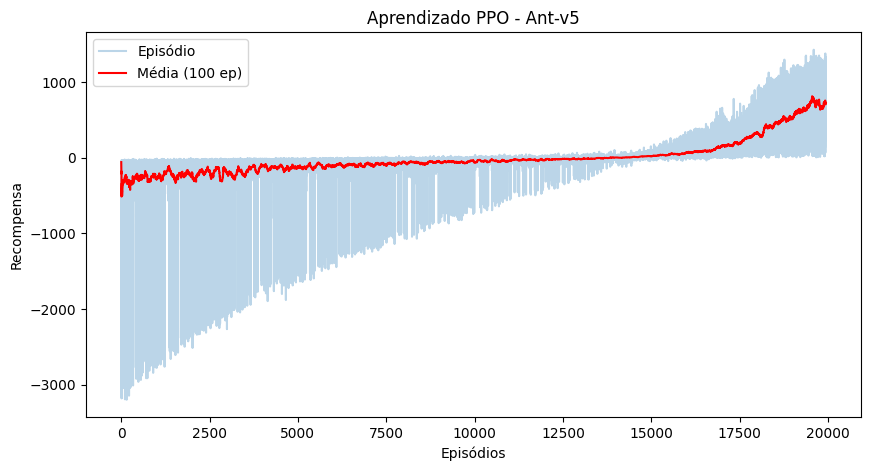


Gerando vídeo de avaliação...


In [8]:
# 6. EXECUÇÃO

if __name__ == "__main__":
    # Inicia o Treino
    rewards, avg_rewards, ppo_agent = train_agent()

    # Plota Resultados
    plt.figure(figsize=(10,5))
    plt.plot(rewards, alpha=0.3, label="Episódio")
    plt.plot(avg_rewards, color="red", label="Média (100 ep)")
    plt.title(f"Aprendizado PPO - {CONFIG['env_name']}")
    plt.xlabel("Episódios"); plt.ylabel("Recompensa")
    plt.legend(); plt.show()

    # Gera Vídeo
    video_file = evaluate_and_record(ppo_agent, f"{CONFIG['model_folder']}/actor_final.pth")



In [ ]:
# Vídeo
print(f"\nExibindo vídeo: {video_file}")
import moviepy.editor as mp
mp.ipython_display(video_file, width=500)